# Library Import

In [71]:
import cv2
import matplotlib.pyplot as plt
import warnings
from keras import Sequential
from keras.src.callbacks import CSVLogger, TensorBoard, EarlyStopping, ModelCheckpoint
from keras.src.layers import BatchNormalization, Dense, MaxPooling2D, Dropout, Conv2D, Activation, Flatten, \
    GlobalAveragePooling2D
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.optimizers import Adam
from keras.src.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.utils import shuffle
import plotly.express as px
import plotly.graph_objects as go
import itertools
from keras.src.regularizers import L2
from mlflow.models.signature import infer_signature
import mlflow
import time
import os
from collections import Counter

warnings.filterwarnings('ignore')

# PATH

In [72]:
TRAIN_PATH = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v19/'
LOG_DIR = 'output/log/v19/'
MODEL_SAVE_PATH = 'output/model/v19/cnn_model_v19.keras'
HISTORY_PATH = 'output/model/v19/train_history_v19.npy'

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

TRAIN_SIZE = 3200
VAL_SIZE = 600
TEST_SIZE = 200

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}
CLASS_NAMES = list(LABEL_MAPPING.keys())
NB_CLASSES = len(CLASS_NAMES)

# Function to load data

In [73]:
def load_data(dataset, label_mapping, image_size=(224, 224)):
    images, labels = [], []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        for folder in os.listdir(dataset_path):
            if folder not in label_mapping:
                continue

            label = label_mapping[folder]
            folder_path = os.path.join(dataset_path, folder)

            for file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, file)

                image = cv2.imread(img_path, cv2.IMREAD_COLOR)
                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, image_size)
                image = image / 255.0

                images.append(image)
                labels.append(label)

    return np.array(images, dtype='float32'), np.array(labels, dtype='int')

In [74]:
def balance_dataset(images, labels, per_class_count=800):
    from sklearn.utils import resample

    images_balanced, labels_balanced = [], []
    labels_int = np.array(labels)

    for class_id in np.unique(labels_int):
        class_indices = np.where(labels_int == class_id)[0]

        class_images = images[class_indices]
        class_labels = labels[class_indices]

        if len(class_images) > per_class_count:
            selected_indices = np.random.choice(len(class_images), per_class_count, replace=False)
            class_images = class_images[selected_indices]
            class_labels = class_labels[selected_indices]

        elif len(class_images) < per_class_count:
            class_images, class_labels = resample(
                class_images, class_labels,
                replace=True, n_samples=per_class_count,
                random_state=42
            )

        images_balanced.extend(class_images)
        labels_balanced.extend(class_labels)

    return np.array(images_balanced), np.array(labels_balanced)

In [75]:
def balanced_split(images, labels, per_class_count):
    images_balanced, labels_balanced = [], []
    labels_int = np.array(labels)

    for class_id in np.unique(labels_int):
        class_indices = np.where(labels_int == class_id)[0]

        selected_indices = np.random.choice(class_indices, per_class_count, replace=False)

        images_balanced.extend(images[selected_indices])
        labels_balanced.extend(labels[selected_indices])

    return np.array(images_balanced), np.array(labels_balanced)

# Execute images and labels

In [76]:
images, labels = load_data(TRAIN_PATH, LABEL_MAPPING)

In [77]:
images, labels = shuffle(images, labels, random_state=42)

In [78]:
train_images, train_labels = balance_dataset(images, labels, per_class_count=800)

val_images, val_labels = balanced_split(images, labels, per_class_count=150)

test_images, test_labels = balanced_split(images, labels, per_class_count=50)

In [79]:
if train_labels.ndim > 1:
    train_labels_int = np.argmax(train_labels, axis=1)
    val_labels_int = np.argmax(val_labels, axis=1)
    test_labels_int = np.argmax(test_labels, axis=1)
else:
    train_labels_int = train_labels
    val_labels_int = val_labels
    test_labels_int = test_labels

print(f"Train samples per class: {Counter(train_labels_int)}")
print(f"Validation samples per class: {Counter(val_labels_int)}")
print(f"Test samples per class: {Counter(test_labels_int)}")

Train samples per class: Counter({0: 800, 1: 800, 2: 800, 3: 800})
Validation samples per class: Counter({0: 150, 1: 150, 2: 150, 3: 150})
Test samples per class: Counter({0: 50, 1: 50, 2: 50, 3: 50})


In [80]:
train_labels = to_categorical(train_labels, num_classes=NB_CLASSES)
val_labels = to_categorical(val_labels, num_classes=NB_CLASSES)
test_labels = to_categorical(test_labels, num_classes=NB_CLASSES)

# Data Augmentation

In [81]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=(0.8, 1.2),
    channel_shift_range=10,
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)

# Visualize dataset

In [82]:
train_labels_int = np.argmax(train_labels, axis=1)

class_counts = Counter(train_labels_int)

class_labels = [CLASS_NAMES[label] for label in class_counts.keys()]
counts = list(class_counts.values())

fig = px.bar(
    x=class_labels,
    y=counts,
    template='plotly_dark',
    color=class_labels,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'},
    text=counts
)

fig.update_layout(
    xaxis_title='Class Label',
    yaxis_title='Count of Images',
    showlegend=False
)

fig.show()

In [83]:
from collections import Counter

train_labels_int = np.argmax(train_labels, axis=1)
val_labels_int = np.argmax(val_labels, axis=1)
test_labels_int = np.argmax(test_labels, axis=1)

train_counts = [Counter(train_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]
val_counts = [Counter(val_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]
test_counts = [Counter(test_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=train_counts,
    name='Train',
    marker=dict(color='blue'),
    text=train_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=val_counts,
    name='Validation',
    marker=dict(color='green'),
    text=val_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=test_counts,
    name='Test',
    marker=dict(color='red'),
    text=test_counts,
    textposition='auto'
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

fig.show()

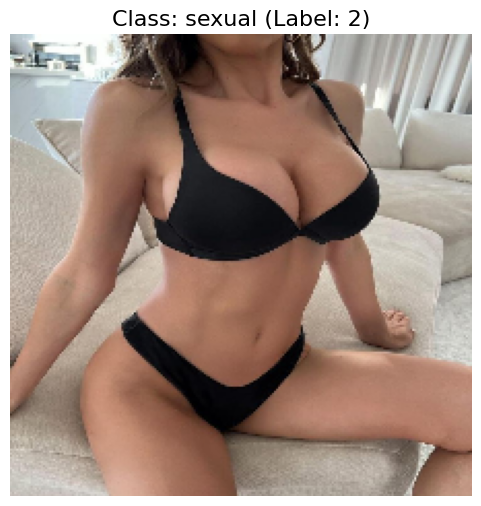

In [84]:
def display_random_image(class_names, images, labels):
    random_index = np.random.randint(0, len(images))

    random_image = images[random_index]
    random_label = labels[random_index]

    if labels.ndim > 1:
        random_label = np.argmax(random_label)

    class_name = class_names[random_label]

    plt.figure(figsize=(6, 6))
    plt.imshow(random_image)
    plt.title(f"Class: {class_name} (Label: {random_label})", fontsize=16, color='black')
    plt.axis('off')
    plt.show()


display_random_image(CLASS_NAMES, train_images, train_labels)

# Display some dataset

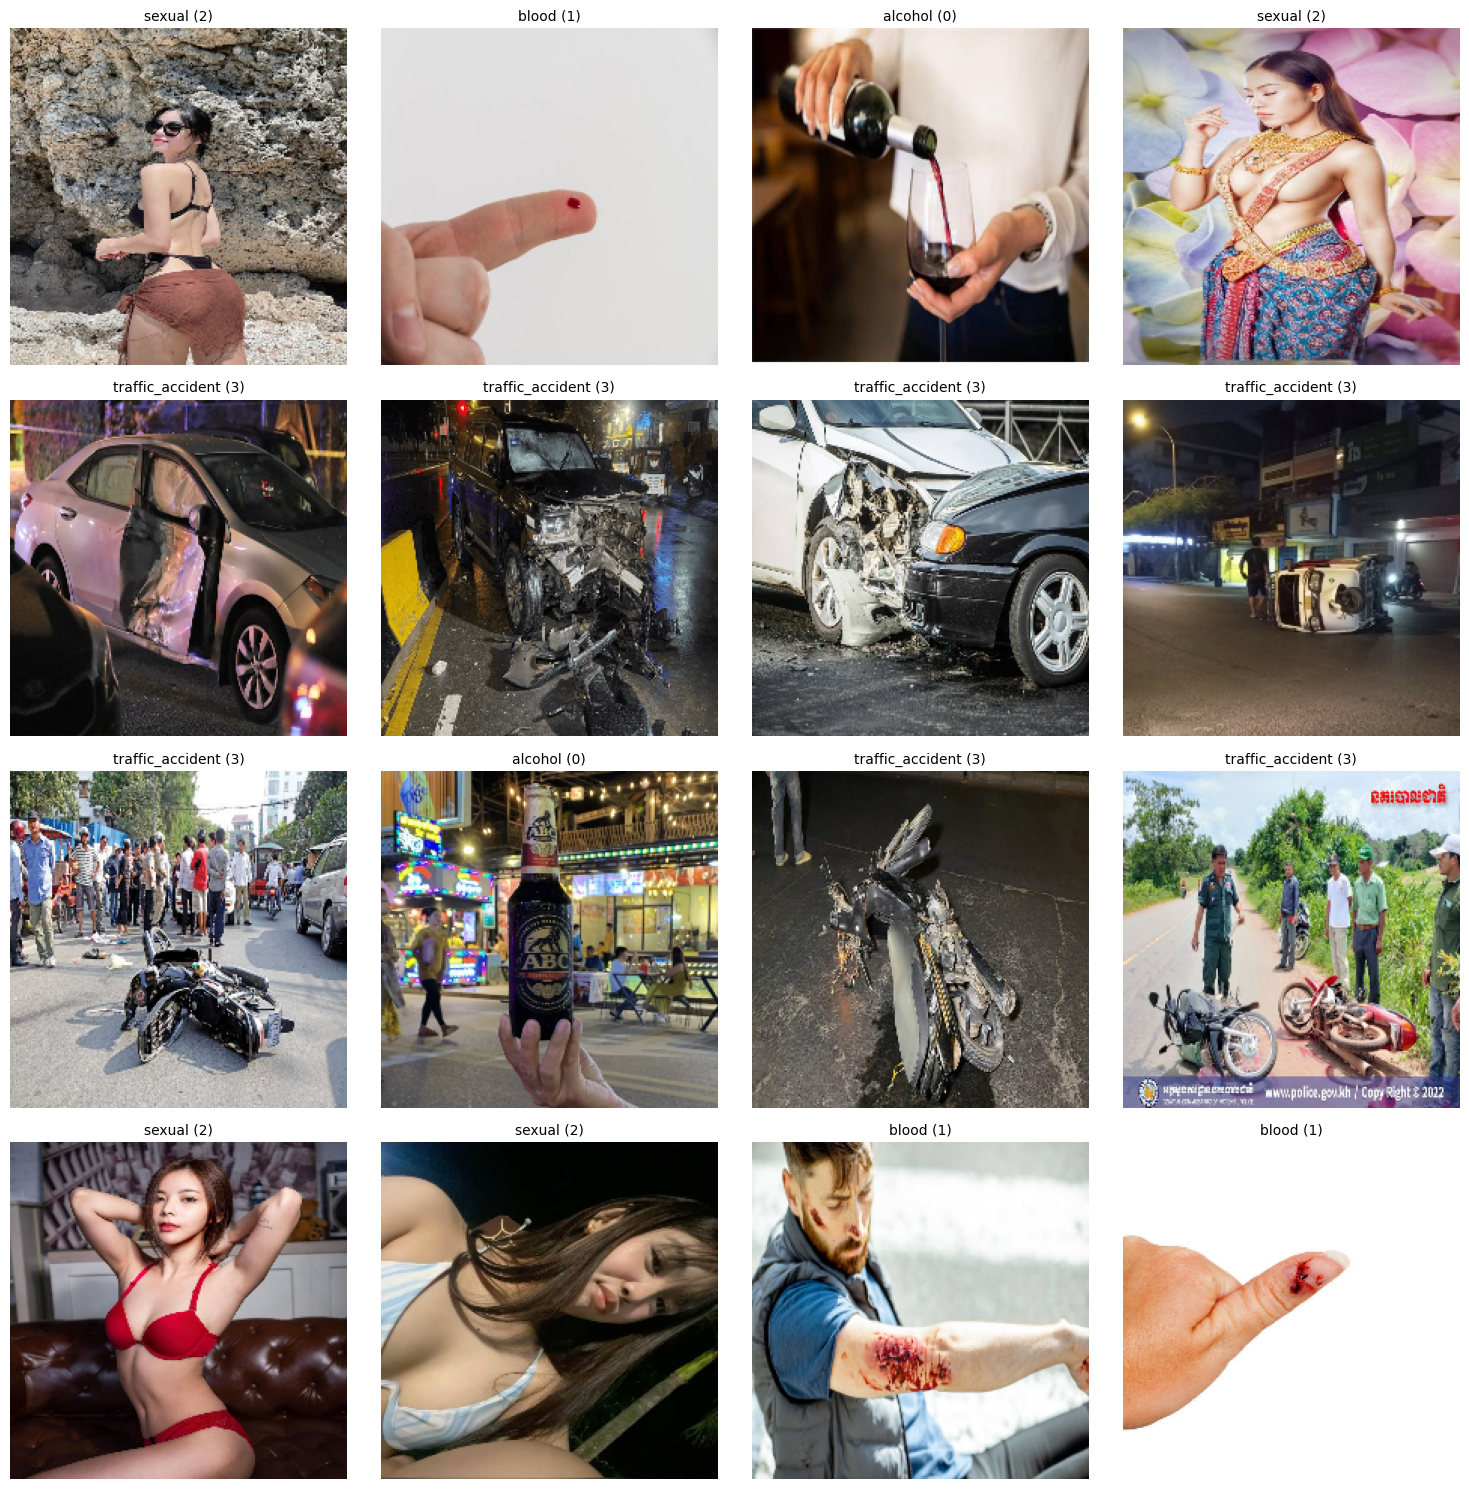

In [85]:
def display_dataset(class_names, images, labels, num_images=16):
    num_images = min(num_images, len(images))

    random_indices = np.random.choice(len(images), num_images, replace=False)

    cols = int(np.sqrt(num_images))
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(15, 15 * rows / cols))

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = labels[idx]

        if labels.ndim > 1:
            label = np.argmax(label)

        class_name = class_names[label]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"{class_name} ({label})", fontsize=10, color='black')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


display_dataset(CLASS_NAMES, train_images, train_labels)

# Model architecture

In [87]:
model = Sequential([
    # First Block
    Conv2D(32, (3, 3), padding='same', input_shape=INPUT_SHAPE, kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Block
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Block
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Fourth Block
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=L2(0.001)),
    Dropout(0.5),

    Dense(NB_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile the model

In [88]:
# MLflow Setup
if mlflow.active_run():
    mlflow.end_run()

MLFLOW_URI = "http://127.0.0.1:5001"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("Model_Training")
mlflow.tensorflow.autolog()

# Optimizer
optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v19.csv'), append=False),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"), histogram_freq=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, save_weights_only=False,
                    verbose=1),
]

# Start MLflow Run
with mlflow.start_run():
    start_time = time.time()

    # Log Hyperparameters
    mlflow.log_params({
        "batch_size": BATCH_SIZE,
        "image_size": IMAGE_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "train_samples": train_generator.n,
        "valid_samples": valid_generator.n,
        "test_samples": test_generator.n,
        "batch_norm_momentum": 0.99,
        "batch_norm_epsilon": 0.001,
    })

    # Train Model
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Track training duration
    training_time = time.time() - start_time
    mlflow.log_metric("training_time_sec", training_time)

    # Log Final Metrics
    final_metrics = {
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_train_loss": history.history["loss"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "final_val_loss": history.history["val_loss"][-1]
    }
    mlflow.log_metrics(final_metrics)

    # Save Model
    model.save(MODEL_SAVE_PATH)
    np.save(HISTORY_PATH, history.history)

    sample_input = np.random.rand(1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3) 
    sample_output = model.predict(sample_input)
    signature = infer_signature(sample_input, sample_output)

    mlflow.tensorflow.log_model(model, artifact_path="train_cnn_model_v19", signature=signature,
                                input_example=sample_input)

    # Log Training Logs
    mlflow.log_artifact(os.path.join(LOG_DIR, 'training_log_v19.csv'), artifact_path="logs")

    print("✅ Training complete and logged to MLflow!")

2025/02/22 10:52:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.
2025/02/22 10:52:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2561 - loss: 1.9694
Epoch 1: val_loss improved from inf to 1.73525, saving model to output/model/v19/cnn_model_v19.keras


100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.2561 - loss: 1.9684 - val_accuracy: 0.2500 - val_loss: 1.7353
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2528 - loss: 1.7187
Epoch 2: val_loss improved from 1.73525 to 1.64832, saving model to output/model/v19/cnn_model_v19.keras


100/100 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.2529 - loss: 1.7184 - val_accuracy: 0.2500 - val_loss: 1.6483
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2396 - loss: 1.6377
Epoch 3: val_loss improved from 1.64832 to 1.58177, saving model to output/model/v19/cnn_model_v19.keras


100/100 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2397 - loss: 1.6375 - val_accuracy: 0.2417 - val_loss: 1.5818
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2483 - loss: 1.5691
Epoch 4: val_loss improved from 1.58177 to 1.53615, saving model to output/model/v19/cnn_model_v19.keras


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.2435 - loss: 1.3866 - val_accuracy: 0.2483 - val_loss: 1.3865
Epoch 48/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2380 - loss: 1.3866
Epoch 48: val_loss improved from 1.38652 to 1.38648, saving model to output/model/v19/cnn_model_v19.keras


100/100 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.2380 - loss: 1.3866 - val_accuracy: 0.1900 - val_loss: 1.3865
Epoch 49/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2693 - loss: 1.3868
Epoch 49: val_loss did not improve from 1.38648
100/100 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.2692 - loss: 1.3869 - val_accuracy: 0.2433 - val_loss: 1.3876
Epoch 50/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2405 - loss: 1.3871
Epoch 50: val_loss improved from 1.38648 to 1.38629, saving model to output/model/v19/cnn_model_v19.keras


100/100 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.2405 - loss: 1.3871 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 51/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2693 - loss: 1.3865
Epoch 51: val_loss did not improve from 1.38629
100/100 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.2690 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3866
Epoch 52/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2482 - loss: 1.3866
Epoch 52: val_loss did not improve from 1.38629
100/100 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.2482 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3873
Epoch 53/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2603 - loss: 1.3868
Epoch 53: val_loss did not improve from 1.38629
100/100 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.2603 - loss: 1.3868 - val_accuracy: 0.2100 - val_loss: 1.3868
Epoch 54/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2662 - loss: 1.3859
Epoch 54: val_loss did not improve f

2025/02/22 13:06:54 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/02/22 13:06:54 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/02/22 13:07:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
✅ Training complete and logged to MLflow!
🏃 View run abrasive-croc-958 at: http://127.0.0.1:5001/#/experiments/640510964062410103/runs/10ae043b66694dbfba8f96d2403d2f50
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/640510964062410103


# Evaluate the model

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step - accuracy: 0.2444 - loss: 1.4344
Test Loss: 1.4383, Test Accuracy: 0.2447
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 854ms/step
Classification Report:
                   precision    recall  f1-score   support

         alcohol       0.00      0.00      0.00       100
           blood       0.24      1.00      0.39        92
          sexual       0.00      0.00      0.00       105
traffic_accident       0.00      0.00      0.00        79

        accuracy                           0.24       376
       macro avg       0.06      0.25      0.10       376
    weighted avg       0.06      0.24      0.10       376



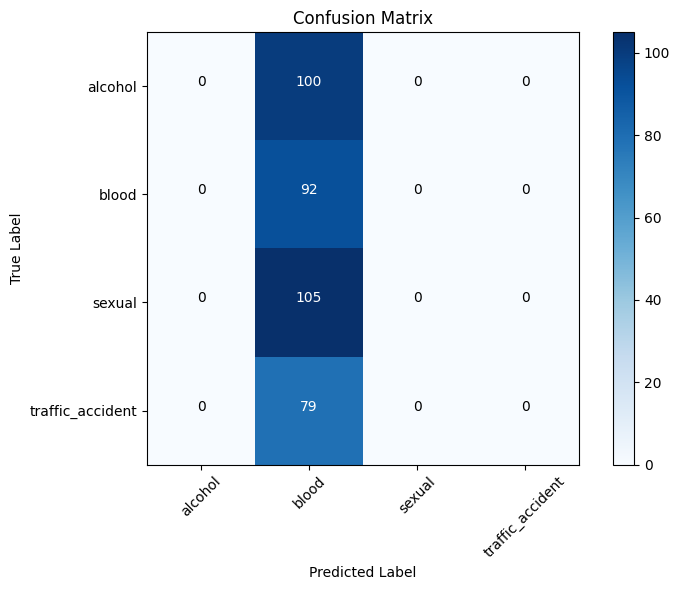

In [31]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
report = classification_report(test_labels, y_pred_classes, target_names=CLASS_NAMES)
print("Classification Report:\n", report)

cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{PLOT_SAVE_DIR}confusion_matrix.png")
plt.show()

In [32]:
from keras.src.saving import load_model

best_model = load_model(MODEL_SAVE_PATH)

test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"✅ Best Model Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 477ms/step - accuracy: 0.2444 - loss: 1.4344
✅ Best Model Accuracy: 0.2447, Loss: 1.4383
